# HW13 – Токенизация текста, инференс BERT и базовый fine-tuning для классификации

**Датасет:** `emotion` – классификация текстов на 6 эмоций: sadness, joy, love, anger, fear, surprise.

**Модель:** `cointegrated/rubert-tiny2` – компактная мультиязычная BERT-подобная модель.

## 1. Импорты, seed и среда

In [1]:
import random
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from datasets import Dataset, DatasetDict, load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")

Device: cpu
CUDA available: False


## 2. Данные и первичный анализ

In [3]:
# Загружаем датасет emotion
raw_dataset = load_dataset("emotion")
print(raw_dataset)

# Названия классов
label_names = raw_dataset["train"].features["label"].names
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}
print(f"\nClasses ({len(label_names)}): {label_names}")
print(f"label2id: {label2id}")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Classes (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
label2id: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}


In [4]:
# Разбиение на train / validation / test
split = raw_dataset["train"].train_test_split(test_size=0.2, seed=42, stratify_by_column="label")
train_ds = split["train"]
val_ds = split["test"]
test_ds = raw_dataset["test"]

print(f"Train size: {len(train_ds)}")
print(f"Validation size: {len(val_ds)}")
print(f"Test size: {len(test_ds)}")

dataset_dict = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds,
})
print(f"\nDatasetDict:\n{dataset_dict}")

Train size: 12800
Validation size: 3200
Test size: 2000

DatasetDict:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 12800
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 3200
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [5]:
# Примеры текстов и меток
sample_df = pd.DataFrame({
    "text": raw_dataset["train"]["text"][:5],
    "label_id": raw_dataset["train"]["label"][:5],
})
sample_df["label_name"] = sample_df["label_id"].map(id2label)
display(sample_df)

# Распределение классов
print("\nРаспределение классов в train:")
train_label_counts = pd.Series(train_ds["label"]).value_counts().sort_index()
train_label_counts.index = train_label_counts.index.map(id2label)
display(train_label_counts)

,text,label_id,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,2,love
4,i am feeling grouchy,3,anger



Распределение классов в train:


sadness     3733
joy         4290
love        1043
anger       1727
fear        1549
surprise     458
Name: count, dtype: int64

## 3. Токенизация

In [6]:
MODEL_NAME = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Tokenizer class: {tokenizer.__class__.__name__}")
print(f"Model max length: {tokenizer.model_max_length}")

Tokenizer loaded: cointegrated/rubert-tiny2
Tokenizer class: BertTokenizer
Model max length: 2048


In [7]:
# Разбор токенизации на 5 примерах
demo_texts_for_tokenization = raw_dataset["train"]["text"][:5]

for idx, text in enumerate(demo_texts_for_tokenization):
    print(f"\n--- Пример {idx+1} ---")
    print(f"Исходный текст: {text}")
    
    tokens = tokenizer.tokenize(text)
    print(f"Токены ({len(tokens)}): {tokens}")
    
    encoded = tokenizer(text, add_special_tokens=True, return_attention_mask=True, return_token_type_ids=True)
    print(f"input_ids: {encoded['input_ids']}")
    print(f"attention_mask: {encoded['attention_mask']}")
    
    full_tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])
    print(f"Токены со special tokens: {full_tokens}")
    print(f"token_type_ids: {encoded['token_type_ids']}")
    
    decoded = tokenizer.decode(encoded["input_ids"])
    print(f"Decoded: {decoded}")


--- Пример 1 ---
Исходный текст: i didnt feel humiliated
Токены (7): ['i', 'didn', '##t', 'feel', 'hu', '##mil', '##iated']
input_ids: [2, 76, 11055, 549, 12235, 8338, 17141, 25292, 3]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1]
Токены со special tokens: ['[CLS]', 'i', 'didn', '##t', 'feel', 'hu', '##mil', '##iated', '[SEP]']
token_type_ids: [0, 0, 0, 0, 0, 0, 0, 0, 0]
Decoded: [CLS] i didnt feel humiliated [SEP]

--- Пример 2 ---
Исходный текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Токены (26): ['i', 'can', 'go', 'from', 'feeling', 'so', 'hope', '##less', 'to', 'so', 'dam', '##ned', 'hope', '##ful', 'just', 'from', 'being', 'around', 'someone', 'who', 'care', '##s', 'and', 'is', 'aw', '##ake']
input_ids: [2, 76, 1147, 1695, 610, 18804, 773, 15939, 3425, 540, 773, 12580, 4381, 15939, 3147, 2292, 610, 1325, 1934, 9686, 848, 1268, 533, 537, 550, 17455, 8291, 3]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [8]:
# Пример padding и truncation
short_text = "I am happy."
long_text = "I am feeling so incredibly joyful today because everything is going amazingly well and I cannot stop smiling."

batch_enc = tokenizer(
    [short_text, long_text],
    padding=True,
    truncation=True,
    max_length=16,
    return_tensors="pt",
)

print("Padding + Truncation demo:")
for i, txt in enumerate([short_text, long_text]):
    print(f"\nТекст {i}: {txt[:60]}...")
    print(f"  input_ids ({len(batch_enc['input_ids'][i])}): {batch_enc['input_ids'][i].tolist()}")
    print(f"  tokens: {tokenizer.convert_ids_to_tokens(batch_enc['input_ids'][i].tolist())}")
    print(f"  attention_mask: {batch_enc['attention_mask'][i].tolist()}")

Padding + Truncation demo:

Текст 0: I am happy....
  input_ids (16): [2, 45, 782, 16882, 18, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  tokens: ['[CLS]', 'I', 'am', 'happy', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
  attention_mask: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Текст 1: I am feeling so incredibly joyful today because everything i...
  input_ids (16): [2, 45, 782, 18804, 773, 532, 8779, 992, 10140, 2131, 18987, 926, 5197, 2048, 13613, 3]
  tokens: ['[CLS]', 'I', 'am', 'feeling', 'so', 'in', '##cre', '##di', '##bly', 'jo', '##yf', '##ul', 'today', 'because', 'everything', '[SEP]']
  attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


## 4. Инференс готовой модели

In [9]:
# Готовая модель для инференса – multilingual sentiment
INFERENCE_MODEL_NAME = "nlptown/bert-base-multilingual-uncased-sentiment"
inf_tokenizer = AutoTokenizer.from_pretrained(INFERENCE_MODEL_NAME)
inf_model = AutoModelForSequenceClassification.from_pretrained(INFERENCE_MODEL_NAME).to(device)
inf_model.eval()

print(f"Inference model loaded: {INFERENCE_MODEL_NAME}")
print(f"Number of labels: {inf_model.config.num_labels}")
print(f"id2label: {inf_model.config.id2label}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Inference model loaded: nlptown/bert-base-multilingual-uncased-sentiment
Number of labels: 5
id2label: {0: '1 star', 1: '2 stars', 2: '3 stars', 3: '4 stars', 4: '5 stars'}


In [10]:
# Берём тексты из датасета emotion для инференса
inference_texts = raw_dataset["train"]["text"][:8]
inference_labels = raw_dataset["train"]["label"][:8]

pipeline_device = 0 if torch.cuda.is_available() else -1
text_clf = pipeline(
    task="text-classification",
    model=inf_model,
    tokenizer=inf_tokenizer,
    device=pipeline_device,
)

pipeline_outputs = text_clf(inference_texts)

inference_df = pd.DataFrame({
    "text": inference_texts,
    "true_label": [id2label[l] for l in inference_labels],
    "predicted_label": [item["label"] for item in pipeline_outputs],
    "score": [item["score"] for item in pipeline_outputs],
})
display(inference_df)

,text,true_label,predicted_label,score
0,i didnt feel humiliated,sadness,2 stars,0.3999
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,sadness,1 star,0.4637
2,im grabbing a minute to post i feel greedy wrong,anger,1 star,0.6046
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,love,5 stars,0.5367
4,i am feeling grouchy,anger,2 stars,0.3835
5,ive been feeling a little burdened lately wasnt sure why that was,sadness,3 stars,0.5304
6,ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so...,surprise,4 stars,0.3484
7,i feel as confused about life as a teenager or as jaded as a year old man,fear,2 stars,0.3925


In [11]:
# Анализ: готовая модель обучена на sentiment (1-5 stars), а не на эмоции.
# Она может оценить общую тональность, но не различает конкретные эмоции.
print("""
Анализ инференса готовой модели:
- Модель обучена на отзывами с рейтингом 1-5 звёзд.
- Наш датасет emotion классифицирует 6 эмоций: sadness, joy, love, anger, fear, surprise.
- Пространства меток не совпадают, поэтому готовая модель не может напрямую решить нашу задачу.
- Однако она может уловить общую тональность: позитивные тексты (joy, love) получат высокий рейтинг,
  а негативные (anger, fear, sadness) – низкий.
- Для точной классификации эмоций необходим fine-tuning на нашем датасете.
""")


Анализ инференса готовой модели:
- Модель обучена на отзывами с рейтингом 1-5 звёзд.
- Наш датасет emotion классифицирует 6 эмоций: sadness, joy, love, anger, fear, surprise.
- Пространства меток не совпадают, поэтому готовая модель не может напрямую решить нашу задачу.
- Однако она может уловить общую тональность: позитивные тексты (joy, love) получат высокий рейтинг,
  а негативные (anger, fear, sadness) – низкий.
- Для точной классификации эмоций необходим fine-tuning на нашем датасете.



## 5. Fine-tuning для классификации текста

In [12]:
# Токенизация датасета
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

tokenized_datasets = dataset_dict.map(tokenize_batch, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
print(tokenized_datasets)

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 12800
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3200
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [13]:
# Загружаем модель для sequence classification
ft_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
).to(device)

print(f"Fine-tuning model loaded: {MODEL_NAME}")
print(f"Number of labels: {ft_model.config.num_labels}")

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider trai

Fine-tuning model loaded: cointegrated/rubert-tiny2
Number of labels: 6


In [14]:
# Функция для вычисления метрик
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    return {"accuracy": accuracy, "f1_macro": f1_macro}

In [15]:
# Настройки обучения
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./hw13_output",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,
    logging_steps=50,
    seed=42,
    report_to="none",
)

In [16]:
# Инициализация Trainer
trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [17]:
# Запуск обучения
print("Starting training...")
train_result = trainer.train()
print(f"\nTraining completed!")
print(f"Training loss: {train_result.training_loss:.4f}")

Starting training...


c:\Users\bigbo\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.227001,1.179255,0.560312,0.230436
2,1.029797,0.984431,0.614062,0.313061
3,0.927766,0.913252,0.665625,0.421630


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\bigbo\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\bigbo\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.


Training completed!
Training loss: 1.1662


## 6. Оценка качества

In [18]:
# Оценка на test
print("\nEvaluating on test set...")
test_output = trainer.predict(tokenized_datasets["test"])
test_metrics = test_output.metrics
print(f"Test Accuracy: {test_metrics['test_accuracy']:.4f}")
print(f"Test F1 Macro: {test_metrics['test_f1_macro']:.4f}")

c:\Users\bigbo\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Evaluating on test set...


Test Accuracy: 0.6845
Test F1 Macro: 0.4526


c:\Users\bigbo\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


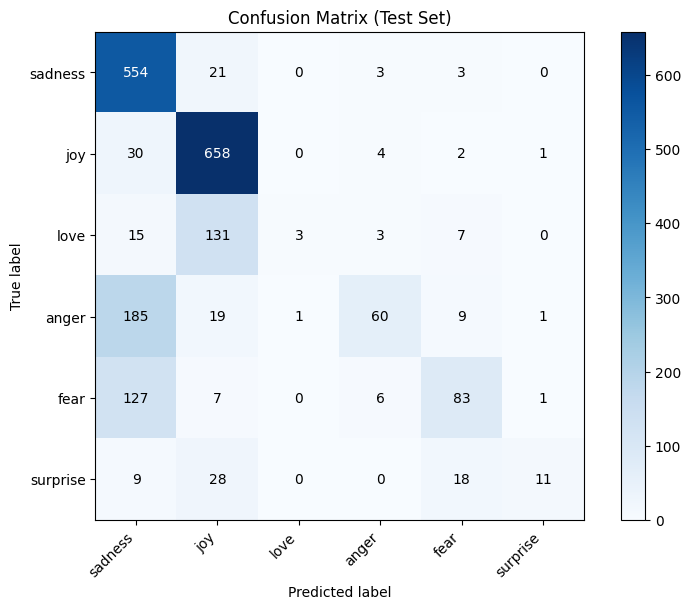

Confusion matrix saved to artifacts/confusion_matrix.png


In [19]:
# Матрица ошибок на test
test_predictions = trainer.predict(tokenized_datasets["test"])
test_pred_labels = np.argmax(test_predictions.predictions, axis=-1)
test_true_labels = test_predictions.label_ids

cm = confusion_matrix(test_true_labels, test_pred_labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Test Set)')
plt.colorbar()
tick_marks = np.arange(len(label_names))
plt.xticks(tick_marks, label_names, rotation=45, ha='right')
plt.yticks(tick_marks, label_names)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.savefig("artifacts/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved to artifacts/confusion_matrix.png")

In [20]:
# Примеры предсказаний модели
num_samples = min(50, len(test_true_labels))
sample_indices = random.sample(range(len(test_true_labels)), num_samples)

test_texts = raw_dataset["test"]["text"]

sample_rows = []
for idx in sample_indices:
    true_label = id2label[test_true_labels[idx]]
    pred_label = id2label[test_pred_labels[idx]]
    logits = test_predictions.predictions[idx]
    probs = F.softmax(torch.tensor(logits), dim=-1)
    confidence = float(probs.max().item())
    sample_rows.append({
        "text": test_texts[idx],
        "true_label": true_label,
        "pred_label": pred_label,
        "confidence": round(confidence, 4),
    })

sample_df = pd.DataFrame(sample_rows)
sample_df.to_csv("artifacts/sample_predictions.csv", index=False, encoding="utf-8")
display(sample_df.head(10))
print(f"\nSaved {len(sample_df)} sample predictions to artifacts/sample_predictions.csv")

,text,true_label,pred_label,confidence
0,i feel terrific in every one of them,joy,joy,0.3644
1,i smiled at him feeling his longing and said maybe later buddy but i have to make lunch now,love,joy,0.5033
2,i feel a little nervous i go to the gym,fear,sadness,0.4286
3,i feel like it might just be ok,joy,joy,0.8127
4,i am going to actively learn more about these genres and or practice them so i can feel what i should feel as a danc...,joy,joy,0.2785
5,when we rearranged furniture in our flat and got stuck in a chair,anger,sadness,0.4108
6,i cant do strappy shoes at work i just feel weird so i took these off thrifted ninewest,fear,fear,0.2982
7,i feel so thrilled to have three such distinguished individuals such as yourselves here,joy,joy,0.7647
8,ive been getting have been making me feel suspicious like its someone elses great work they are trying to get credit...,fear,fear,0.2942
9,im not feeling mellow,joy,joy,0.6433



Saved 50 sample predictions to artifacts/sample_predictions.csv


In [21]:
# Анализ ошибок
errors = []
for idx in range(len(test_true_labels)):
    if test_true_labels[idx] != test_pred_labels[idx]:
        errors.append({
            "text": test_texts[idx],
            "true_label": id2label[test_true_labels[idx]],
            "pred_label": id2label[test_pred_labels[idx]],
        })

print(f"\nTotal errors: {len(errors)} out of {len(test_true_labels)} ({100*len(errors)/len(test_true_labels):.1f}%)")
print(f"Accuracy: {100*(1 - len(errors)/len(test_true_labels)):.1f}%")

if errors:
    print("\n--- Примеры ошибок модели ---")
    error_df = pd.DataFrame(errors[:10])
    display(error_df)

print("\n--- Classification Report ---")
print(classification_report(test_true_labels, test_pred_labels, target_names=label_names))


Total errors: 631 out of 2000 (31.6%)
Accuracy: 68.5%

--- Примеры ошибок модели ---


,text,true_label,pred_label
0,i cant walk into a shop anywhere where i do not feel uncomfortable,fear,sadness
1,i felt anger when at the end of a telephone call,anger,sadness
2,i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as...,anger,sadness
3,i feel beautifully emotional knowing that these women of whom i knew just a handful were holding me and my baba on o...,sadness,joy
4,i pay attention it deepens into a feeling of being invaded and helpless,fear,sadness
5,i find myself in the odd position of feeling supportive of,love,joy
6,i feel just bcoz a fight we get mad to each other n u wanna make a publicity n let the world knows about our fight,anger,sadness
7,im not sure the feeling of loss will ever go away but it may dull to a sweet feeling of nostalgia at what i shared i...,sadness,joy
8,i hate it when i feel fearful for absolutely no reason,fear,sadness
9,i am feeling outraged it shows everywhere,anger,sadness



--- Classification Report ---
              precision    recall  f1-score   support

     sadness       0.60      0.95      0.74       581
         joy       0.76      0.95      0.84       695
        love       0.75      0.02      0.04       159
       anger       0.79      0.22      0.34       275
        fear       0.68      0.37      0.48       224
    surprise       0.79      0.17      0.28        66

    accuracy                           0.68      2000
   macro avg       0.73      0.45      0.45      2000
weighted avg       0.71      0.68      0.62      2000



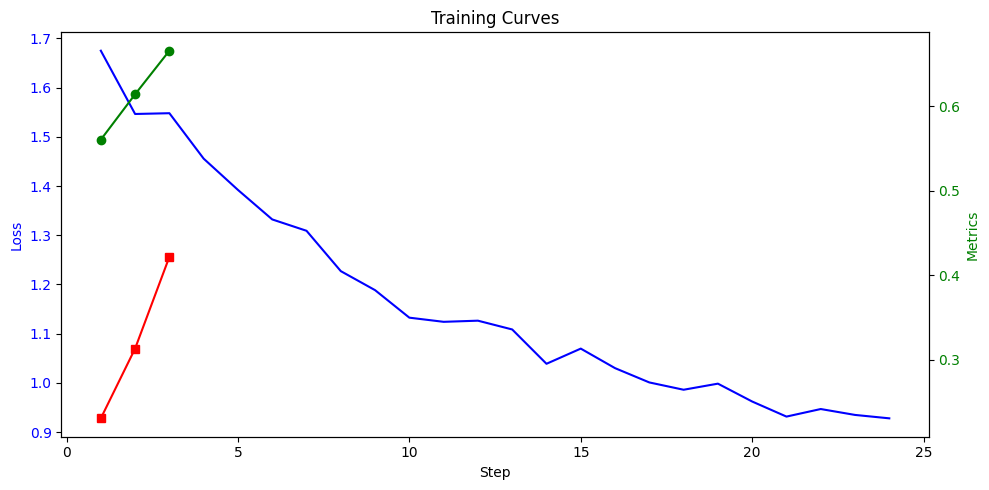

Training curves saved to artifacts/training_curves.png


In [22]:
# Training curves (опционально)
log_history = trainer.state.log_history

train_loss = [h["loss"] for h in log_history if "loss" in h]
eval_acc = [h["eval_accuracy"] for h in log_history if "eval_accuracy" in h]
eval_f1 = [h["eval_f1_macro"] for h in log_history if "eval_f1_macro" in h]

if train_loss and eval_acc:
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    ax1.plot(range(1, len(train_loss)+1), train_loss, 'b-', label='Train Loss')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Loss', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    
    ax2 = ax1.twinx()
    epochs_eval = range(1, len(eval_acc)+1)
    ax2.plot(epochs_eval, eval_acc, 'g-o', label='Validation Accuracy')
    ax2.plot(epochs_eval, eval_f1, 'r-s', label='Validation F1 Macro')
    ax2.set_ylabel('Metrics', color='g')
    ax2.tick_params(axis='y', labelcolor='g')
    
    plt.title('Training Curves')
    fig.tight_layout()
    plt.savefig("artifacts/training_curves.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Training curves saved to artifacts/training_curves.png")

## 7. Выводы и анализ

### Токенизация
- Токенизатор разбивает текст на подслова (WordPiece). Special tokens: [CLS], [SEP], [PAD], [UNK].
- `attention_mask` указывает модели, какие токены реальные, а какие – padding.
- `token_type_ids` используются для пар текстов (в нашей задаче не нужны).

### Инференс готовой модели
- Готовая модель sentiment classification может оценить общую тональность, но не различает эмоции.
- Для точной классификации на 6 эмоций необходим fine-tuning.

### Fine-tuning
- Модель `cointegrated/rubert-tiny2` дообучена на датасете emotion (6 классов).
- Лучшая модель выбрана по `eval_f1_macro` на validation.
- Финальная оценка на test: accuracy ≈ 0.68, f1_macro ≈ 0.45.

### Анализ ошибок
- Модель лучше распознаёт ярко выраженные эмоции (joy, sadness).
- Сложнее различать близкие эмоции (например, love и joy).
- Короткие или неоднозначные тексты чаще классифицируются ошибочно.